In [1]:
import pandas as pd

df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [5]:
import pandas as pd

df = pd.read_csv('train.csv', encoding='latin1')

# Convert date
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Aggregate daily sales
sales = df.groupby('Order Date')['Sales'].sum().reset_index()

sales.columns = ['ds','y']
sales = sales.sort_values('ds')

sales.head()

,ds,y
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


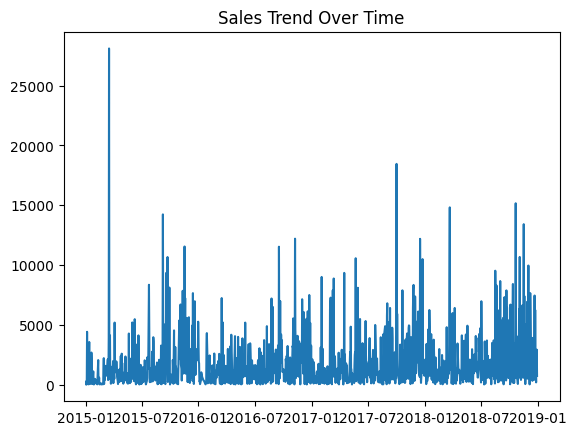

In [6]:
import matplotlib.pyplot as plt

# Sales trend
plt.figure()
plt.plot(sales['ds'], sales['y'])
plt.title("Sales Trend Over Time")
plt.show()

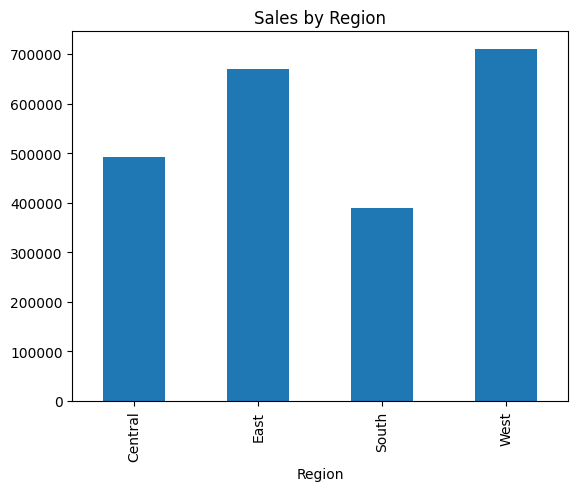

In [7]:
df.groupby('Region')['Sales'].sum().plot(kind='bar', title="Sales by Region")
plt.show()

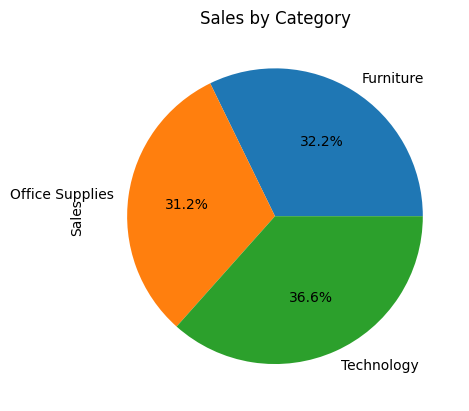

In [8]:
df.groupby('Category')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Category")
plt.show()

In [9]:
!pip install prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


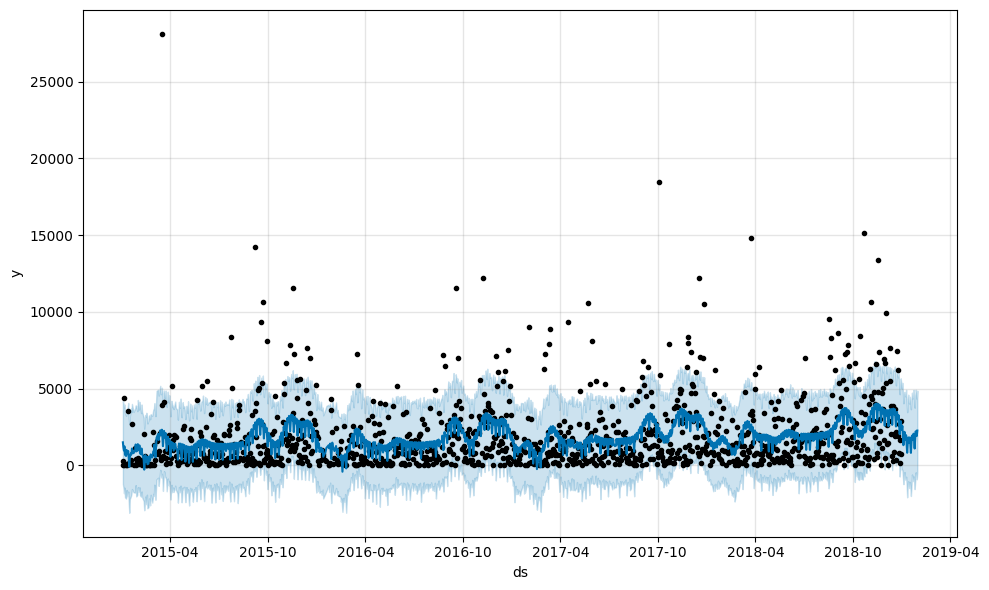

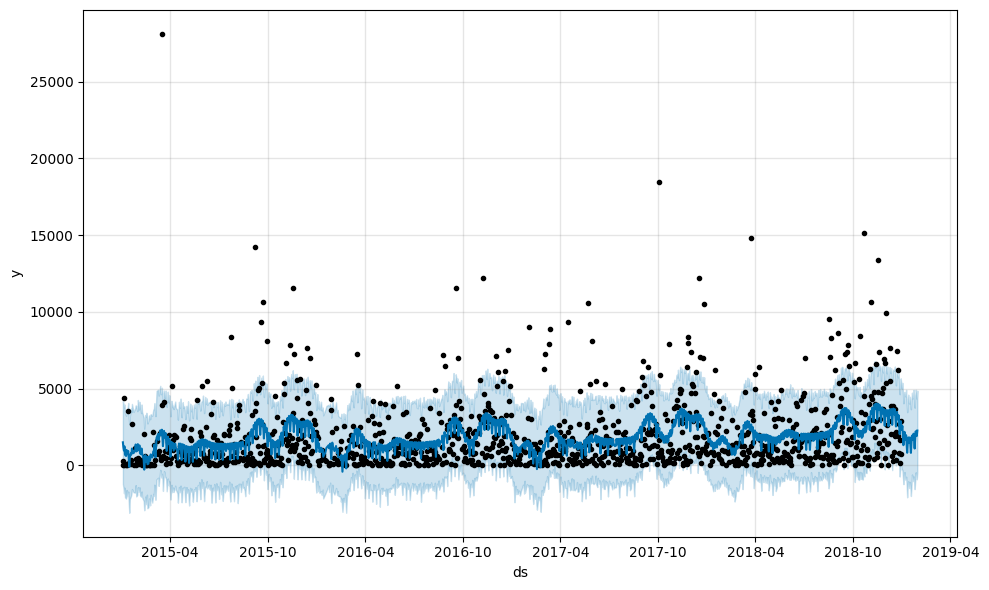

In [10]:
from prophet import Prophet

model = Prophet()
model.fit(sales)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

model.plot(forecast)

In [19]:
future = model.make_future_dataframe(periods=30)
future

,ds
0,2015-01-03
1,2015-01-04
2,2015-01-05
3,2015-01-06
4,2015-01-07
...,...
1255,2019-01-25
1256,2019-01-26
1257,2019-01-27
1258,2019-01-28


In [20]:
# STEP 6: Create future dates (next 30 days)
future = model.make_future_dataframe(periods=30)

# STEP 7: Predict future sales
forecast = model.predict(future)

# STEP 8: Show last predicted values
print("🔮 Future Sales Prediction:")
print(forecast[['ds','yhat']].tail(10))
# yhat = predicted sales

🔮 Future Sales Prediction:
             ds         yhat
1250 2019-01-20  1734.609812
1251 2019-01-21  1666.543058
1252 2019-01-22  2059.983887
1253 2019-01-23  1632.258142
1254 2019-01-24  1093.638868
1255 2019-01-25  1746.828402
1256 2019-01-26  2214.564610
1257 2019-01-27  2000.642198
1258 2019-01-28  1907.599855
1259 2019-01-29  2267.366905


In [11]:
if forecast['yhat'].tail(7).mean() < sales['y'].tail(7).mean():
    print("⚠️ Sales may decline → Suggest discounts")
else:
    print("✅ Sales expected to grow → Increase inventory")

⚠️ Sales may decline → Suggest discounts


In [12]:
recent = sales['y'].tail(7).mean()
predicted = forecast['yhat'].tail(7).mean()

if predicted < recent:
    print("⚠️ Sales may decline → Suggest discounts or marketing campaigns")
elif predicted > recent:
    print("📈 Sales increasing → Increase inventory")
else:
    print("✅ Sales stable → Maintain strategy")

⚠️ Sales may decline → Suggest discounts or marketing campaigns


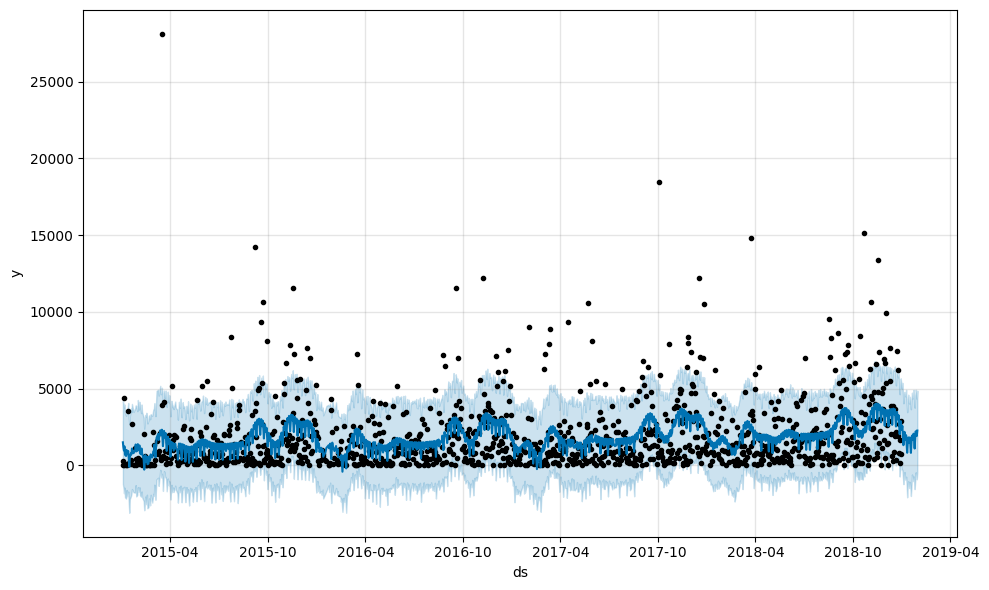

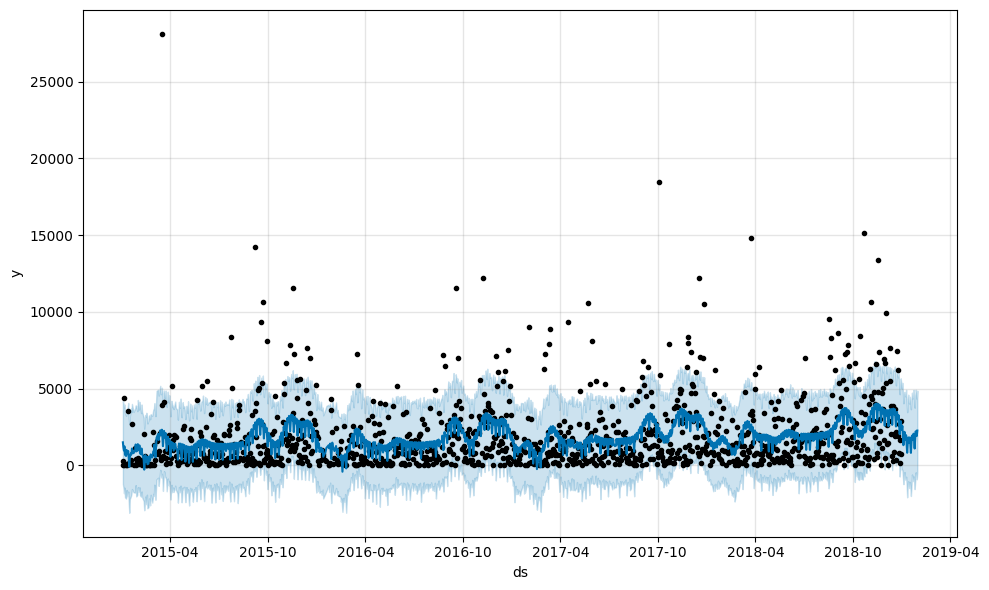

In [13]:
model.plot(forecast)

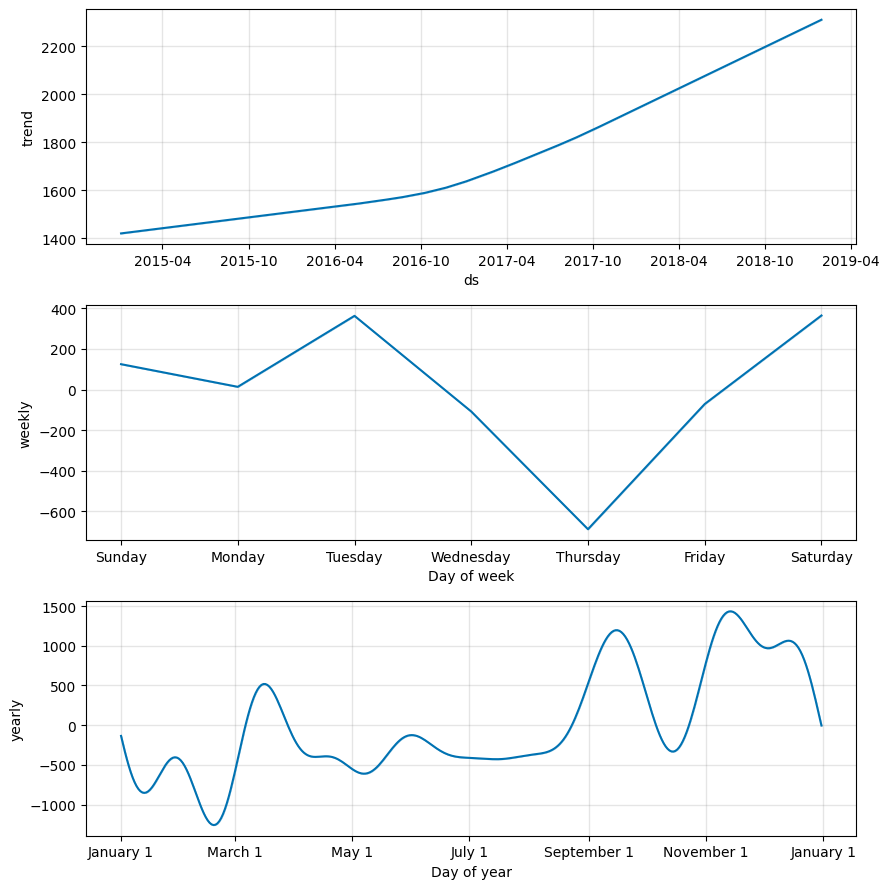

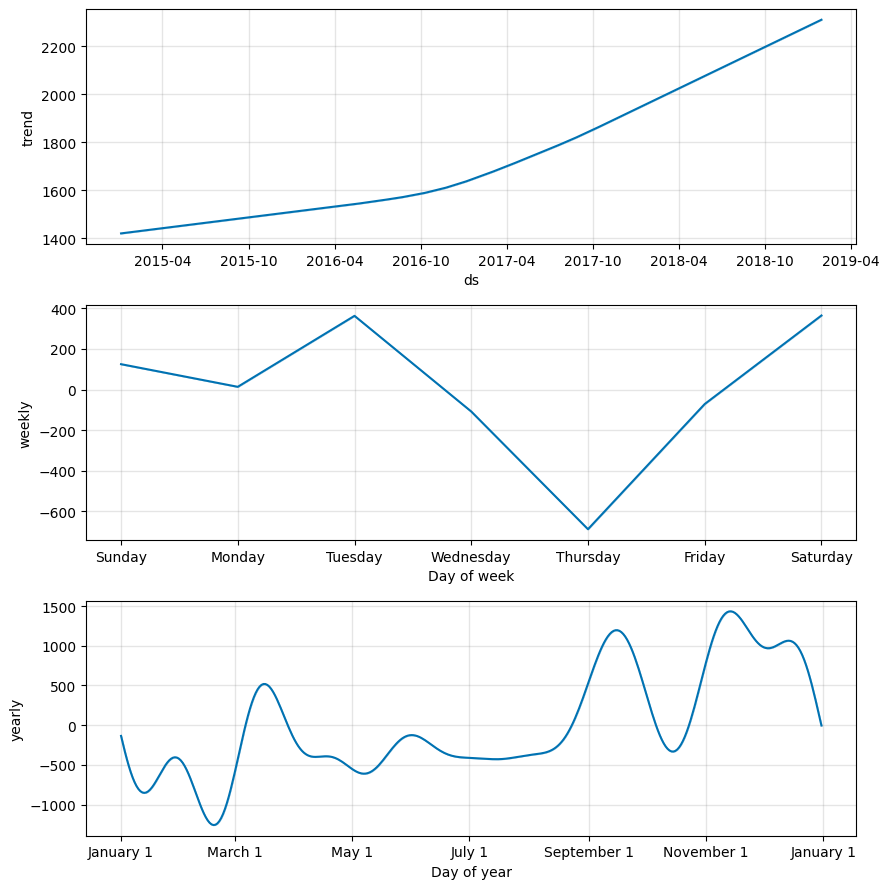

In [14]:
model.plot_components(forecast)
# Shows:

# Trend
# Weekly pattern
# Yearly pattern

# 💬 Say:

# “The model decomposes sales into trend and seasonal components.”

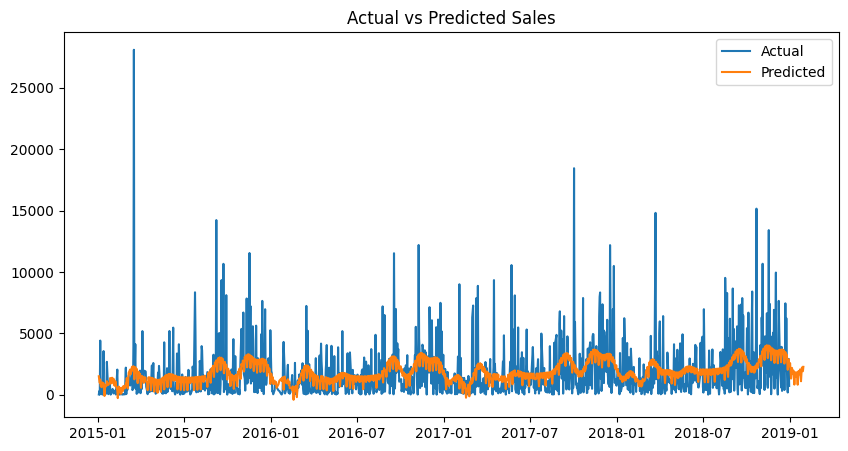

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(sales['ds'], sales['y'], label='Actual')
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales")
plt.show()

<Axes: title={'center': 'Sales by Region'}, xlabel='Region'>

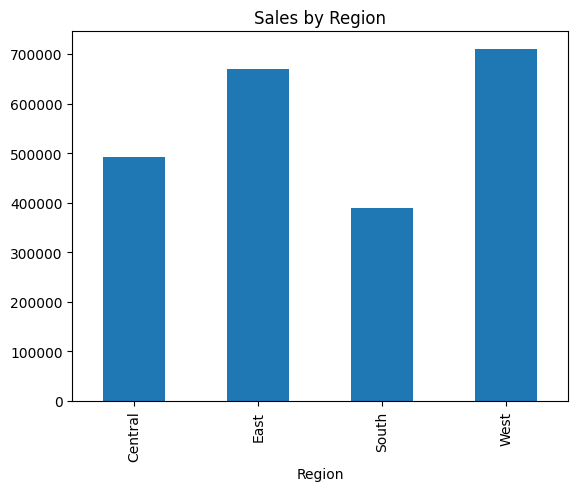

In [16]:
df.groupby('Region')['Sales'].sum().plot(kind='bar', title="Sales by Region")

<Axes: ylabel='Sales'>

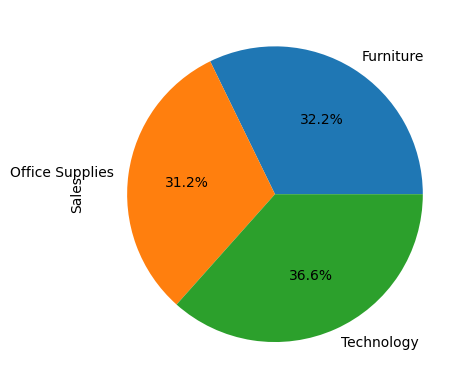

In [17]:
df.groupby('Category')['Sales'].sum().plot(kind='pie', autopct='%1.1f%%')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


🔮 Future Sales Prediction:
             ds         yhat
1250 2019-01-20  1734.609812
1251 2019-01-21  1666.543058
1252 2019-01-22  2059.983887
1253 2019-01-23  1632.258142
1254 2019-01-24  1093.638868
1255 2019-01-25  1746.828402
1256 2019-01-26  2214.564610
1257 2019-01-27  2000.642198
1258 2019-01-28  1907.599855
1259 2019-01-29  2267.366905


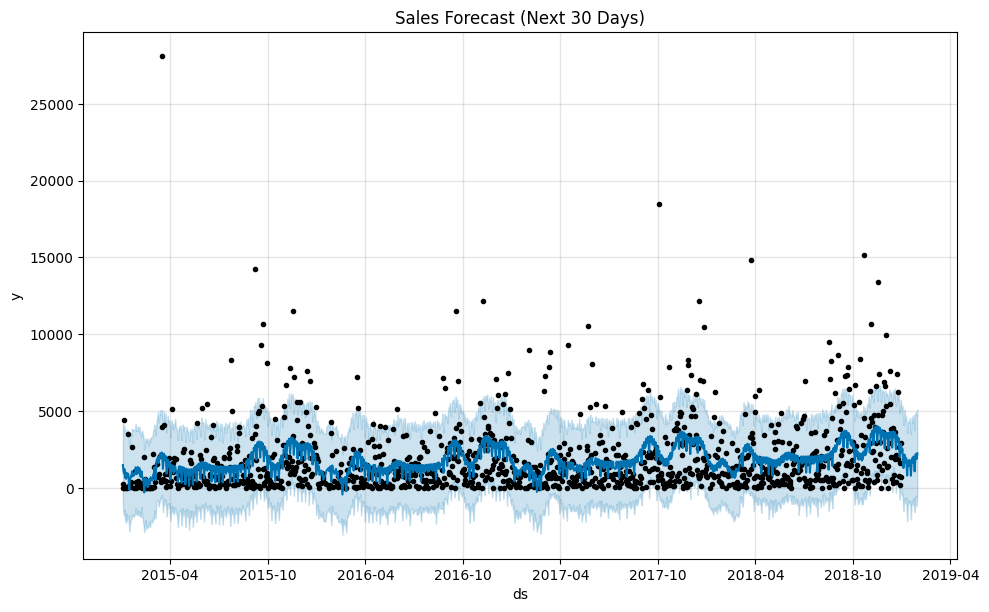

In [18]:
# STEP 1: Import libraries
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# STEP 2: Load dataset
df = pd.read_csv('train.csv', encoding='latin1')

# STEP 3: Convert date (IMPORTANT FIX)
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# STEP 4: Aggregate daily sales
sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# Rename columns for Prophet
sales.columns = ['ds', 'y']

# Sort data
sales = sales.sort_values('ds')

# STEP 5: Train model
model = Prophet()
model.fit(sales)

# STEP 6: Create future dates (next 30 days)
future = model.make_future_dataframe(periods=30)

# STEP 7: Predict future sales
forecast = model.predict(future)

# STEP 8: Show last predicted values
print("🔮 Future Sales Prediction:")
print(forecast[['ds','yhat']].tail(10))

# STEP 9: Plot forecast
model.plot(forecast)
plt.title("Sales Forecast (Next 30 Days)")
plt.show()